## Import required modules and Loading data for clustering

In [45]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering, DBSCAN, OPTICS, Birch, AffinityPropagation, MeanShift, estimate_bandwidth

from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

sns.set_theme('notebook')


In [46]:
filename=r"D:\HopeAI\Assignments\ML and DS Capstone\4. Feature Selection\dataset_unscaled.pkl"
dataset = pickle.load(open(filename,'rb'))

filename=r"D:\HopeAI\Assignments\ML and DS Capstone\4. Feature Selection\scaler.pkl"
scaler = pickle.load(open(filename,'rb'))
dataset_scaled = scaler.transform(dataset)
dataset_scaled


array([[0.1101939 , 0.46846779, 0.47663295, ..., 0.55555556, 0.53088626,
        0.44489057],
       [0.1101939 , 0.07030888, 0.69874747, ..., 0.44444444, 0.6226675 ,
        0.48710729],
       [0.1101939 , 0.14692181, 0.53061738, ..., 0.44444444, 0.54949402,
        0.67223213],
       ...,
       [0.08394156, 0.04715308, 0.15223356, ..., 0.11111111, 0.34292081,
        0.79772467],
       [0.08394156, 0.25850936, 0.14961553, ..., 0.44444444, 0.35189318,
        0.61496189],
       [0.08394156, 0.28245404, 0.17498031, ..., 0.66666667, 0.33328033,
        0.58644438]], shape=(484, 11))

In [ ]:

filename=r"D:\HopeAI\Assignments\ML and DS Capstone\4. Feature Selection\pca.pkl"
pca = pickle.load(open(filename,'rb'))
X_pca = pca.transform(dataset_scaled)


## Clustering

### Finding best clustering model

In [31]:
results = {}

def count_clusters(labels):
    # Number of clusters excluding noise label (-1)
    return len(set(labels)) - (1 if -1 in labels else 0)

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_pca)
results['KMeans'] = (count_clusters(kmeans_labels), silhouette_score(X_pca, kmeans_labels))

# Agglomerative
agg = AgglomerativeClustering(n_clusters=3)
agg_labels = agg.fit_predict(X_pca)
results['Agglomerative'] = (count_clusters(agg_labels), silhouette_score(X_pca, agg_labels))

# Gaussian Mixture
gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(X_pca)
results['GaussianMixture'] = (count_clusters(gmm_labels), silhouette_score(X_pca, gmm_labels))

# Spectral Clustering
spectral = SpectralClustering(n_clusters=3, random_state=42, affinity='nearest_neighbors')
spectral_labels = spectral.fit_predict(X_pca)
results['SpectralClustering'] = (count_clusters(spectral_labels), silhouette_score(X_pca, spectral_labels))

# Birch
birch = Birch(n_clusters=3)
birch_labels = birch.fit_predict(X_pca)
results['Birch'] = (count_clusters(birch_labels), silhouette_score(X_pca, birch_labels))

# DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_pca)
n_clusters_dbscan = count_clusters(dbscan_labels)
if n_clusters_dbscan > 1:
    score = silhouette_score(X_pca, dbscan_labels)
else:
    score = np.nan
results['DBSCAN'] = (n_clusters_dbscan, score)

# OPTICS
optics = OPTICS(min_samples=5)
optics_labels = optics.fit_predict(X_pca)
n_clusters_optics = count_clusters(optics_labels)
if n_clusters_optics > 1:
    score = silhouette_score(X_pca, optics_labels)
else:
    score = np.nan
results['OPTICS'] = (n_clusters_optics, score)

# Affinity Propagation
aff_prop = AffinityPropagation(random_state=42)
aff_labels = aff_prop.fit_predict(X_pca)
n_clusters_aff = count_clusters(aff_labels)
if n_clusters_aff > 1:
    score = silhouette_score(X_pca, aff_labels)
else:
    score = np.nan
results['AffinityPropagation'] = (n_clusters_aff, score)

# Mean Shift
mean_shift = MeanShift()
ms_labels = mean_shift.fit_predict(X_pca)
n_clusters_ms = count_clusters(ms_labels)
if n_clusters_ms > 1:
    score = silhouette_score(X_pca, ms_labels)
else:
    score = np.nan
results['MeanShift'] = (n_clusters_ms, score)

# Convert to DataFrame
df_results = pd.DataFrame.from_dict(results, orient='index', columns=['Num_Clusters', 'Silhouette_Score'])

# Replace NaN silhouette scores with a message or keep as NaN
df_results['Silhouette_Score'] = df_results['Silhouette_Score'].apply(
    lambda x: "Not available" if pd.isna(x) else f"{x:.4f}"
)

# Print the table
print(df_results)

print('\nTop 5 Algorithms for Clustering:')
top2_algos = df_results[df_results['Silhouette_Score'] != 'Not available'].sort_values(by='Silhouette_Score', ascending=False).head(5)
top2_algos


                     Num_Clusters Silhouette_Score
KMeans                          3           0.2324
Agglomerative                   3           0.2139
GaussianMixture                 3           0.1878
SpectralClustering              3           0.2190
Birch                           3           0.1263
DBSCAN                          1    Not available
OPTICS                          5          -0.2879
AffinityPropagation            38           0.1612
MeanShift                       1    Not available

Top 5 Algorithms for Clustering:


,Num_Clusters,Silhouette_Score
KMeans,3,0.2324
SpectralClustering,3,0.2190
Agglomerative,3,0.2139
GaussianMixture,3,0.1878
AffinityPropagation,38,0.1612


### 1. Choosing Spectral based on score

In [32]:
# Spectral Clustering
spectral = SpectralClustering(n_clusters=3, random_state=42, affinity='nearest_neighbors')
labels = spectral.fit_predict(X_pca)
(n_clusters, score) = (count_clusters(labels), silhouette_score(X_pca, labels))
print('No of Clusters :', n_clusters, 'and Silhoutte score :', round(score,3))


No of Clusters : 3 and Silhoutte score : 0.219


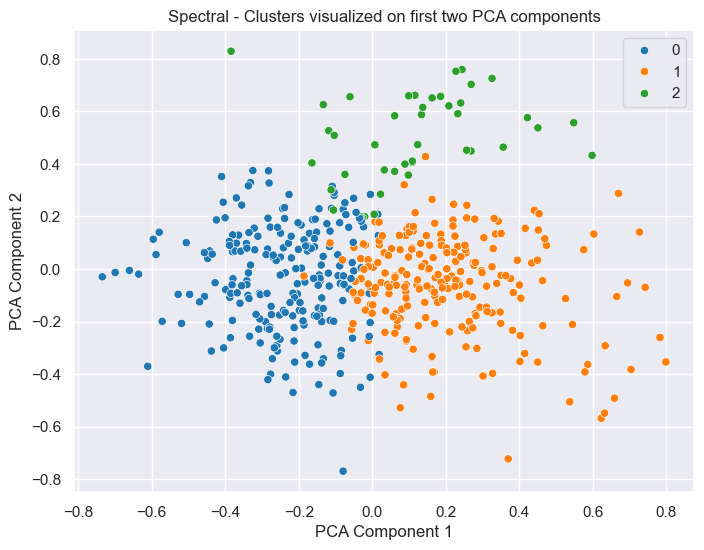

In [33]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette='tab10')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Spectral - Clusters visualized on first two PCA components')
plt.show()


In [34]:
pd.Series(labels).value_counts()


1    227
0    214
2     43
Name: count, dtype: int64

### 2. Choosing KMeans based on score

In [35]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_pca)
(n_clusters, score) = (count_clusters(labels), silhouette_score(X_pca, labels))
print('No of Clusters :', n_clusters, 'and Silhoutte score :', round(score,3))



No of Clusters : 3 and Silhoutte score : 0.232


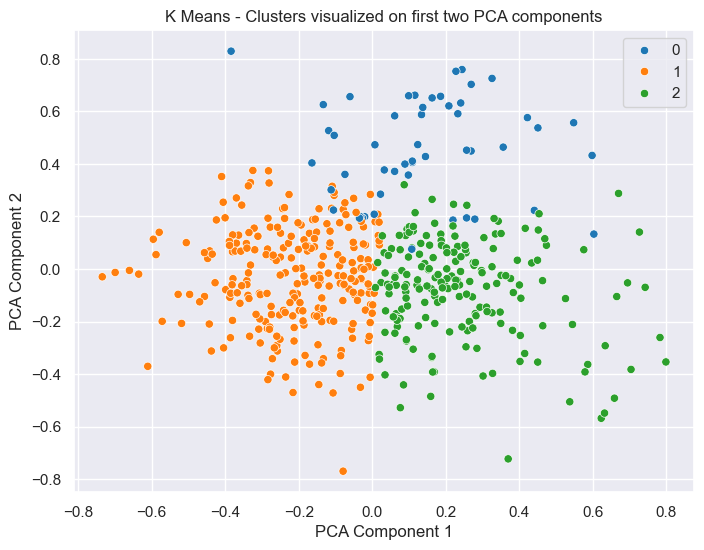

In [36]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette='tab10')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('K Means - Clusters visualized on first two PCA components')
plt.show()


Even though silhouette score for K Means is lower than Mean Shift, it produces three well-balanced, distinct clusters.
Spectral Clustering creates two well-separated large clusters, but the third cluster is very small and scattered, making interpretation tricky

## Choosing K Means for clustering

In [37]:
kmeans = KMeans(n_clusters=3, random_state=50)
labels = kmeans.fit_predict(X_pca)


In [38]:
pd.Series(labels).value_counts()


0    196
1    187
2    101
Name: count, dtype: int64

In [39]:

supervised=dataset
supervised['Cluster_group']=labels

filename=r'D:\HopeAI\Assignments\ML and DS Capstone\4. Feature Selection\dataset_reduced.pkl'
dataset_reduced = pickle.load(open(filename,'rb'))
dataset_reduced['Cluster_group']=labels


#### Understanding what each cluster means

In [40]:
# Grouped means for each feature by Cluster_group:
means = supervised.groupby('Cluster_group').mean()
means


,Market Cap,Total_Annual_Return,Std_Monthly_Return,Max_Drawdown,Pos_Days_Pct,Avg_Daily_TR,Avg_Volume,Volume_Spike_Pct,Months_Pos_Pct,Beta_vs_NIFTY,Corr_with_NIFTY
Cluster_group,,,,,,,,,,,
0,5.065264e+12,42.925364,6.714800,15.469802,52.945695,25.156511,6.721719e+06,6.120139,67.810761,0.852036,0.431779
1,3.605928e+12,-0.210658,7.372573,25.465906,48.630661,26.664642,6.161099e+06,6.092688,46.621293,0.906388,0.472105
2,3.955128e+12,28.744784,13.001431,35.432580,52.055862,22.838926,1.992099e+07,6.170140,59.765977,1.387354,0.627828


**Clusters Category Definition**

| Cluster | Category Name          | Reason                                                        |
|:--------:|:----------------------:|:-------------------------------------------------------------|
| 0        | Low Risk               |Steady returns, least drawdown|
| 1        | High Risk              |Higher drawdown, least months positive |
| 2        | Moderate Risk          |Very volatile and high drawdown, extreme beta, but not the least positive months|


In [41]:
dataset_reduced['Categories'] = dataset_reduced['Cluster_group'].map({0:'Low Risk', 1:'High Risk', 2:'Moderate Risk'})



In [42]:
filename='supervised.pkl'
pickle.dump(supervised, open(filename,'wb'))
filename='full_dataset.pkl'
pickle.dump(dataset_reduced, open(filename,'wb'))
